# Matplotlib Box Plots
Sala Gandu Concept hai poora

Load data.

In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\KAIF FIROZ\anaconda3\envs\kaifs_python_project\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Only get data analyst jobs in India.
df_DA_IND = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'India')].copy()

# Drop NaN values from the column for plotting 
df_DA_IND = df_DA_IND.dropna(subset=['salary_year_avg'])

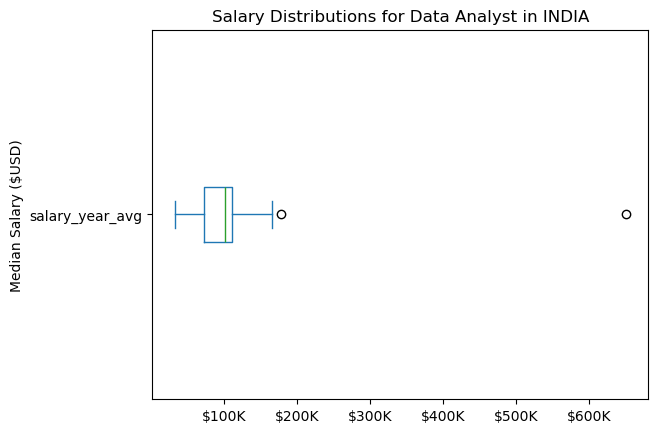

In [9]:
df_DA_IND['salary_year_avg'].plot(kind='box', vert=False)
# Alternatively, you can use matplotlib
# plt.boxplot(df_DA_US['salary_year_avg'])

ax= plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))


plt.title('Salary Distributions for Data Analyst in INDIA')
plt.ylabel('Median Salary ($USD)')
plt.show()

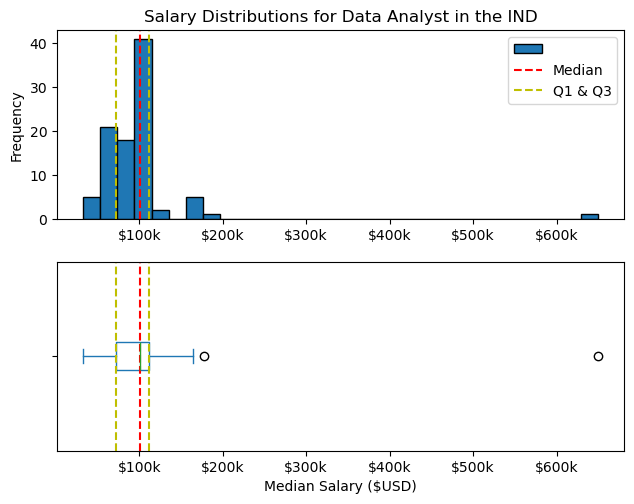

In [11]:
# plot histogram and boxplot for df_DA_IND['salary_year_avg'] on same figure

fig, ax = plt.subplots(2, 1)
fig.tight_layout(h_pad=1)

df_DA_IND['salary_year_avg'].plot(kind='hist', ax=ax[0], bins=30, edgecolor='black')
ax[0].set_title('Salary Distributions for Data Analyst in the IND')
ax[0].set_xlabel('')
ax[0].set_ylabel('Frequency')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: '${0:g}k'.format(x/1000)))
# lines
ax[0].axvline(df_DA_IND['salary_year_avg'].median(), color='r', linestyle='--')
ax[0].axvline(df_DA_IND['salary_year_avg'].quantile(0.25), color='y', linestyle='--')
ax[0].axvline(df_DA_IND['salary_year_avg'].quantile(0.75), color='y', linestyle='--')
ax[0].legend(['', 'Median', 'Q1 & Q3'])


df_DA_IND['salary_year_avg'].plot(kind='box', ax=ax[1], vert=False)
ax[1].set_yticklabels('')
ax[1].set_xlabel('Median Salary ($USD)')
ax[1].set_ylabel('')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: '${0:g}k'.format(x/1000)))
# lines
ax[1].axvline(df_DA_IND['salary_year_avg'].median(), color='r', linestyle='--')
ax[1].axvline(df_DA_IND['salary_year_avg'].quantile(0.25), color='y', linestyle='--')
ax[1].axvline(df_DA_IND['salary_year_avg'].quantile(0.75), color='y', linestyle='--')
plt.show()

In [13]:
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

# filter for the job titles and country
df_IND = df[(df['job_title_short'].isin(job_titles)) & (df['job_country'] == 'India')].dropna(subset=['salary_year_avg'])

C:\Users\KAIF FIROZ\AppData\Local\Temp\ipykernel_11816\3315528356.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(job_list, labels=job_titles, vert=False)


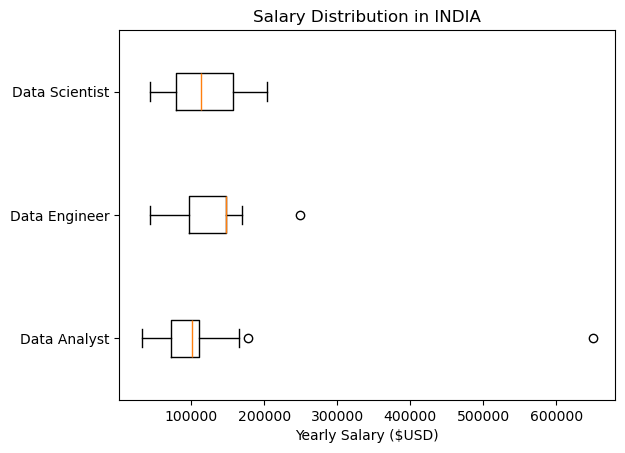

In [14]:
# list of salaries for each job title
job_list = [df_IND[df_IND['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_titles]

plt.boxplot(job_list, labels=job_titles, vert=False)
plt.title('Salary Distribution in INDIA')
plt.xlabel('Yearly Salary ($USD)')
plt.show()

C:\Users\KAIF FIROZ\AppData\Local\Temp\ipykernel_11816\1628338720.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(job_list, labels=job_titles, vert=False)


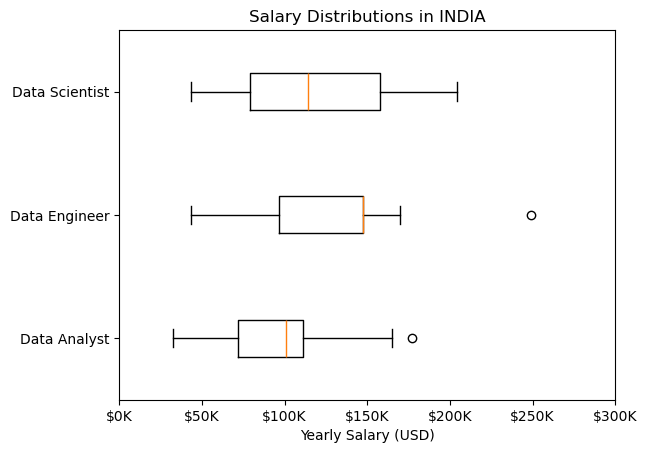

In [18]:
plt.boxplot(job_list, labels=job_titles, vert=False)
plt.title('Salary Distributions in INDIA')
plt.xlabel('Yearly Salary (USD)')
plt.xlim(0, 300000) 

# Format x-axis to show 'Thousands'
ticks_x = plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K')
plt.gca().xaxis.set_major_formatter(ticks_x)
plt.show()